Loading BokehJS ...

/root/miniconda3/lib/python3.9/site-packages/pyfolio/pos.py:26: UserWarning: Module "zipline.assets" not found; mutltipliers will not be applied to position notionals.
  warnings.warn(



获取最新A股交易日期...
当前获取的A股日期是： 20220927

获取上一个交易日...
当前获取的A股日期是： 20220927

加载历史数据...
正在处理股票：正在处理股票：正在处理股票：正在处理股票：正在处理股票：  SZ300171  SZ300282SZ000521 

SZ000068SZ002118


正在处理股票：正在处理股票：  正在处理股票：正在处理股票：正在处理股票：  SZ000721 SZ000929

SZ000428正在处理股票：SZ002693
 正在处理股票：正在处理股票：SZ002543正在处理股票：  
 SZ002033SZ002909正在处理股票：SZ000899正在处理股票：
正在处理股票：
SZ002634
  
正在处理股票：正在处理股票： SZ002561SZ002641
  SZ003027SZ002480

SZ002551正在处理股票：

正在处理股票：正在处理股票：
 正在处理股票：正在处理股票：SZ001238SZ002750SZ002615正在处理股票：  正在处理股票：   SZ002272SZ000756正在处理股票：
正在处理股票：
SZ002084 
 


正在处理股票：SZ002339SZ001267正在处理股票：正在处理股票：

  SZ300203正在处理股票：

SZ002490  正在处理股票：SZ300370SZ002223
SZ002621正在处理股票：正在处理股票：正在处理股票：  SZ000584正在处理股票： 

正在处理股票：正在处理股票：SZ002622
SZ002650 正在处理股票： 
SZ300601  SZ000610SZ002426
SZ002397

  
SZ300015正在处理股票：
正在处理股票：正在处理股票：正在处理股票：
正在处理股票：正在处理股票： 正在处理股票：正在处理股票：   SZ300595    SZ002468
SZ000550SZ300003SZ300133SZ000572SZ000888正在处理股票：SZ002707






 正在处理股票：SZ000430 正在处理股票：正在处理股票：正在处理股票：SZ000799
 SZ002332 正在处理股票：
正在处理股票：正在处理股票：
 正在处理股票：  SZ0020

/root/miniconda3/lib/python3.9/site-packages/pyfolio/timeseries.py:724: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  stats = pd.Series()
/root/miniconda3/lib/python3.9/site-packages/pyfolio/timeseries.py:724: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  stats = pd.Series()
/root/miniconda3/lib/python3.9/site-packages/pyfolio/timeseries.py:724: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  stats = pd.Series()


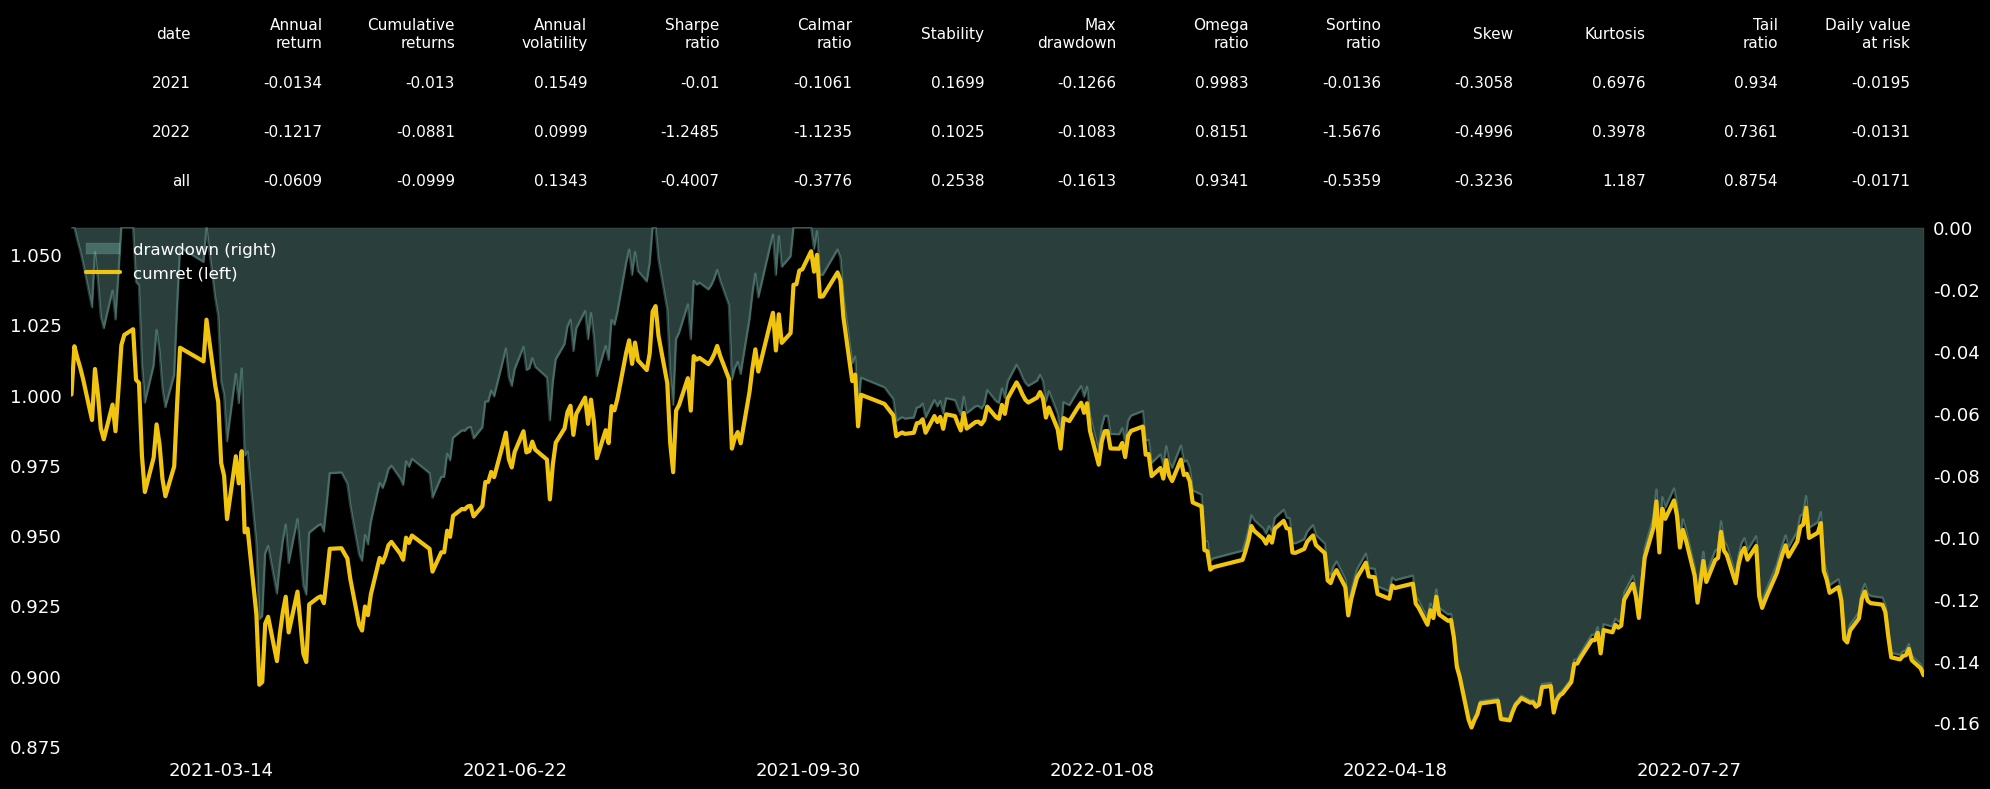

In [1]:
#!/usr/bin/env python3
# -*- coding: UTF-8 -*-

from os import close
import backtrader as bt
from utility.ToolKit import ToolKit
from datetime import datetime
from datetime import datetime, timedelta
from backtrader_plotting import Bokeh
from backtrader_plotting.schemes import Tradimo
from backtraderref.BTStrategyVol import BTStrategyVol
from utility.TickerInfo import TickerInfo
from backtraderref.BTPandasDataExt import BTPandasDataExt
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pyfolio as pf
import pandas as pd


if __name__ == "__main__":

    """创建cerebro对象"""
    cerebro = bt.Cerebro()
    """ 添加bt相关的策略 """
    cerebro.addstrategy(BTStrategyVol)
    """ 初始资金100M """
    cerebro.broker.setcash(1000000.0)
    """ 每手10股 """
    cerebro.addsizer(bt.sizers.FixedSize, stake=100)
    """ 费率千分之一 """
    cerebro.broker.setcommission(commission=0.001, stocklike=True)
    """ 添加股票当日即历史数据 """
    trade_date = ToolKit("获取最新A股交易日期").get_cn_latest_trade_date(1)
    list = TickerInfo(trade_date, "cn").get_backtrader_data_feed()
    """ 循环初始化数据进入cerebro """
    for h in list:
        print("正在初始化: ", h["symbol"][0])
        """ 历史数据最早不超过2021-01-01 """
        data = BTPandasDataExt(
            dataname=h, name=h["symbol"][0], fromdate=datetime(2021, 1, 1)
        )
        cerebro.adddata(data)

    print("Starting Portfolio Value: %.2f" % cerebro.broker.getvalue())

    # 回测时需要添加 TimeReturn 分析器
    cerebro.addanalyzer(bt.analyzers.TimeReturn, _name='_TimeReturn')
    result = cerebro.run()

    print("当前现金持有: ", cerebro.broker.get_cash())
    print("Final Portfolio Value: %.2f" % cerebro.broker.getvalue())

    # 提取收益序列
    pnl = pd.Series(result[0].analyzers._TimeReturn.get_analysis())

    # 计算累计收益
    cumulative = (pnl + 1).cumprod()

    # 计算回撤序列
    max_return = cumulative.cummax()

    drawdown = (cumulative - max_return) / max_return

    # 按年统计收益指标
    perf_stats_year = (
        (pnl)
        .groupby(pnl.index.to_period("y"))
        .apply(lambda data: pf.timeseries.perf_stats(data))
        .unstack()
    )

    # 统计所有时间段的收益指标
    perf_stats_all = pf.timeseries.perf_stats((pnl)).to_frame(name="all")

    perf_stats = pd.concat([perf_stats_year, perf_stats_all.T], axis=0)

    perf_stats_ = round(perf_stats, 4).reset_index()


    # 绘制图形

    plt.rcParams["axes.unicode_minus"] = False  # 用来正常显示负号

    # 导入设置坐标轴的模块
    plt.style.use("seaborn")
    plt.style.use('dark_background')

    fig, (ax0, ax1) = plt.subplots(
        2, 1, gridspec_kw={"height_ratios": [1.5, 4]}, figsize=(20, 8)
    )

    cols_names = [
        "date",
        "Annual\nreturn",
        "Cumulative\nreturns",
        "Annual\nvolatility",
        "Sharpe\nratio",
        "Calmar\nratio",
        "Stability",
        "Max\ndrawdown",
        "Omega\nratio",
        "Sortino\nratio",
        "Skew",
        "Kurtosis",
        "Tail\nratio",
        "Daily value\nat risk",
    ]


    # 绘制表格
    ax0.set_axis_off()
    # 除去坐标轴
    table = ax0.table(
        cellText=perf_stats_.values,
        bbox=(0, 0, 1, 1),
        # 设置表格位置， (x0, y0, width, height)
        rowLoc="right",
        # 行标题居中
        cellLoc="right",
        colLabels=cols_names,
        # 设置列标题
        colLoc="right",
        # 列标题居中
        edges="open",  # 不显示表格边框
    )

    table.set_fontsize(13)


    # 绘制累计收益曲线
    ax2 = ax1.twinx()

    ax1.yaxis.set_ticks_position("right")
    # 将回撤曲线的 y 轴移至右侧
    ax2.yaxis.set_ticks_position("left")
    # 将累计收益曲线的 y 轴移至左侧
    # 绘制回撤曲线
    drawdown.plot.area(
        ax=ax1, label="drawdown (right)", rot=0, alpha=0.3, fontsize=13, grid=False
    )

    # 绘制累计收益曲线
    (cumulative).plot(
        ax=ax2,
        color="#F1C40F",
        lw=3.0,
        label="cumret (left)",
        rot=0,
        fontsize=13,
        grid=False,
    )

    # 不然 x 轴留有空白
    ax2.set_xbound(lower=cumulative.index.min(), upper=cumulative.index.max())

    # 主轴定位器：每 5 个月显示一个日期：根据具体天数来做排版
    ax2.xaxis.set_major_locator(ticker.MultipleLocator(100))

    # 同时绘制双轴的图例
    h1, l1 = ax1.get_legend_handles_labels()

    h2, l2 = ax2.get_legend_handles_labels()

    plt.legend(h1 + h2, l1 + l2, fontsize=12, loc="upper left", ncol=1)


    fig.tight_layout()
    plt.savefig('TRdraw.png')

In [2]:
# 规整排版
plt.show()